# Building a Soft Voting Ensemble

In [19]:
# importing the libraries
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

In [20]:
# load the dataset
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()

,LineOfCode,IsHTTPS,URLLength,CharContinuationRate,LetterRatioInURL,NoOfDegitsInURL,DegitRatioInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,LargestLineLength,label
0,558,1,31,1.000000,0.581,0,0.0,1,0.032,9381,1
1,618,1,23,0.666667,0.391,0,0.0,2,0.087,9381,1
2,467,1,29,0.866667,0.517,0,0.0,2,0.069,682,1
3,6356,1,26,1.000000,0.500,0,0.0,1,0.038,26824,1
4,6089,1,33,1.000000,0.606,0,0.0,1,0.030,28404,1


In [21]:
# split the dataset into features and target variable
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Recreating the individual models

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [23]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [24]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",

    n_estimators=413,
    max_depth=7,
    learning_rate=0.04636499344142013,
    subsample=0.8574269294896713,
    colsample_bytree=0.9497327922401264,
    gamma=0.10616955533913808,
    min_child_weight=1
)

In [25]:
# Build the ensemble model
ensemble = VotingClassifier(

    estimators=[
        ("lr", lr),
        ("rf", rf),
        ("xgb", xgb)
    ],

    voting="soft",

    n_jobs=-1
)

In [26]:
# Train the ensemble model
ensemble.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",-1
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...ndom_state=42), RandomForestC...ndom_state=42), XGBClassifier...ree=None, ...)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U26](10,)","['LineOfCode','IsHTTPS','URLLength',...,'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL','LargestLineLength']"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()


In [27]:
# Predict the test set
y_pred = ensemble.predict(X_test)

y_prob = ensemble.predict_proba(X_test)[:,1]

In [28]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc = roc_auc_score(y_test, y_prob)

In [29]:
# Display the metrics
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]

})

results

,Metric,Value
0,Accuracy,0.999788
1,Precision,0.999815
2,Recall,0.999815
3,F1 Score,0.999815
4,ROC-AUC,0.999996


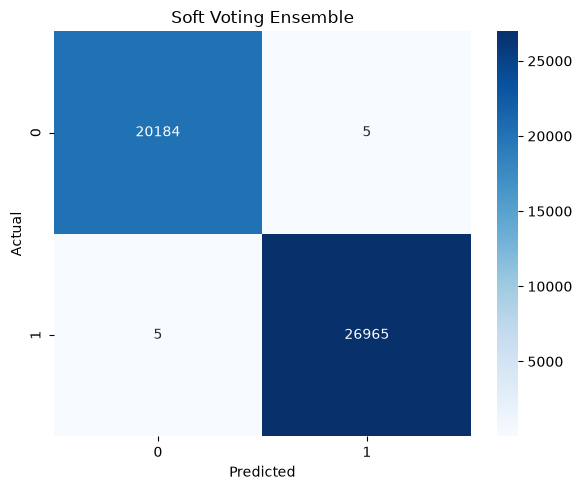

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Soft Voting Ensemble")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../reports/figures/confusion_matrix_ensemble.png")

plt.show()

In [31]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



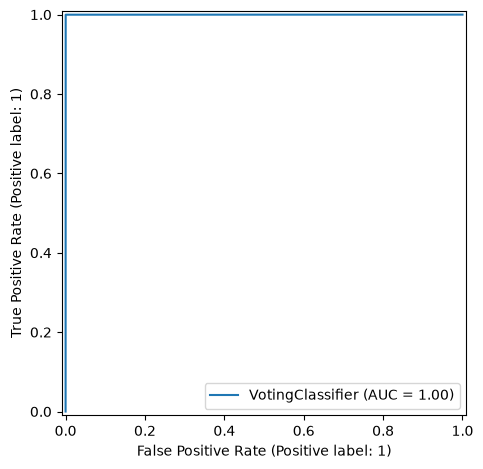

In [32]:
# ROC Curve
RocCurveDisplay.from_estimator(
    ensemble,
    X_test,
    y_test
)

plt.tight_layout()

plt.savefig("../reports/figures/roc_ensemble.png")

plt.show()

In [33]:
# save model
joblib.dump(
    ensemble,
    "../models/ensemble.pkl"
)

['../models/ensemble.pkl']

In [34]:
# save metrics
results.to_csv(
    "../results/ensemble_metrics.csv",
    index=False
)

In [35]:
# comparison
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Baseline XGBoost",
        "Tuned XGBoost",
        "Soft Voting Ensemble"
    ],

    "Accuracy":[
        0.9979219237049132,
        0.9997243368179987,
        0.9997879513984606,
        0.9997879513984606,
        0.9997879513984606
    ],

    "Precision":[
        0.9974453905960755,
        0.9998516595586872,
        0.9997775470858669,
        0.9997775470858669,
        0.9998146088246199
    ],

    "Recall":[
        0.9989247311827957,
        0.9998516595586872,
        0.999851687059696,
        0.999851687059696,
        0.9998146088246199
    ],

    "F1":[
        0.9981845127825121,
        0.9996662958843159,
        0.9998146156983426,
        0.9998146156983426,
        0.9998146088246199
    ],

    "ROC-AUC":[
        0.9997592421619403,
        0.9997589691295078,
        0.9999963002573402,
        0.9999951468999857,
        0.9999960973178693
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.997922,0.997445,0.998925,0.998185,0.999759
1,Random Forest,0.999724,0.999852,0.999852,0.999666,0.999759
2,Baseline XGBoost,0.999788,0.999778,0.999852,0.999815,0.999996
3,Tuned XGBoost,0.999788,0.999778,0.999852,0.999815,0.999995
4,Soft Voting Ensemble,0.999788,0.999815,0.999815,0.999815,0.999996


In [36]:
comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)